## Iris Flower Classification

Goal: Build a classification model to predict iris flower species using features.

Steps:
- Data Exploration & Visualization
- Data Preprocessing
- Model Training
- Evaluation

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load Data

In [15]:
iris = load_iris()

data1 = pd.DataFrame(iris.data, columns=iris.feature_names)
data1['target'] = iris.target

data1['species'] = data1['target'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

print(data1.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


## Visualization

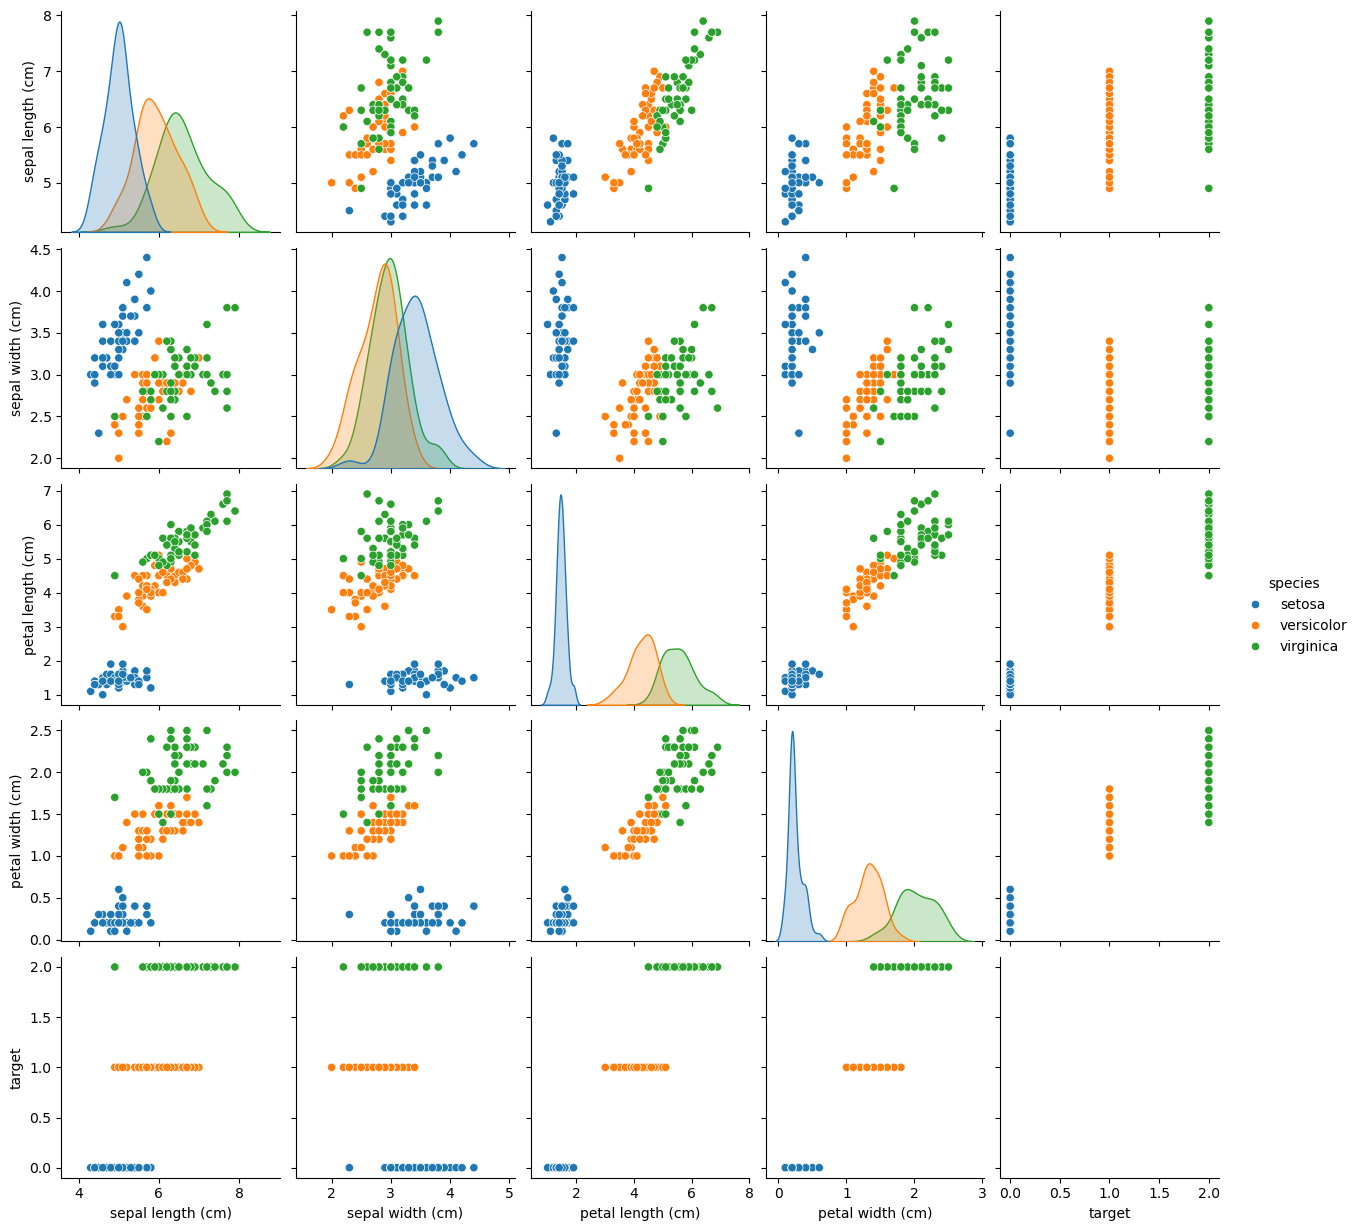

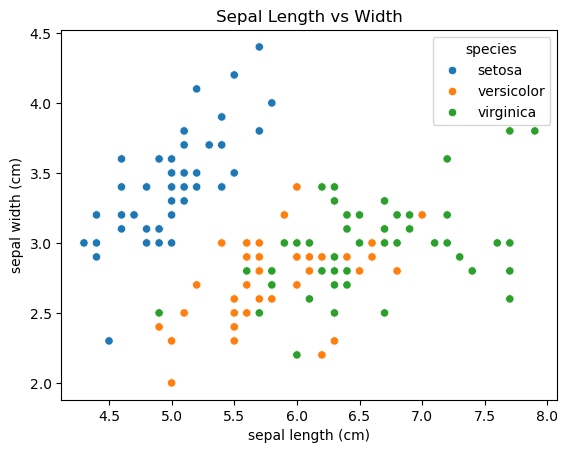

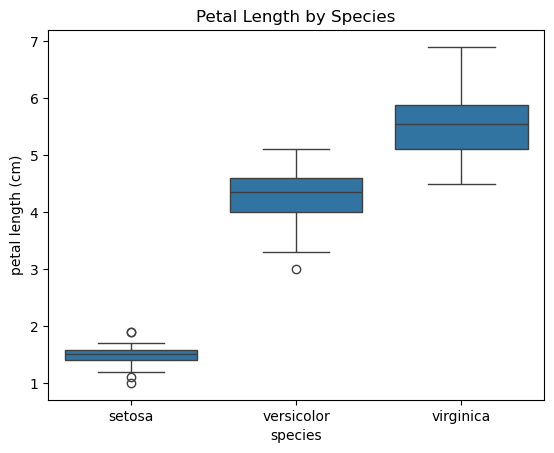

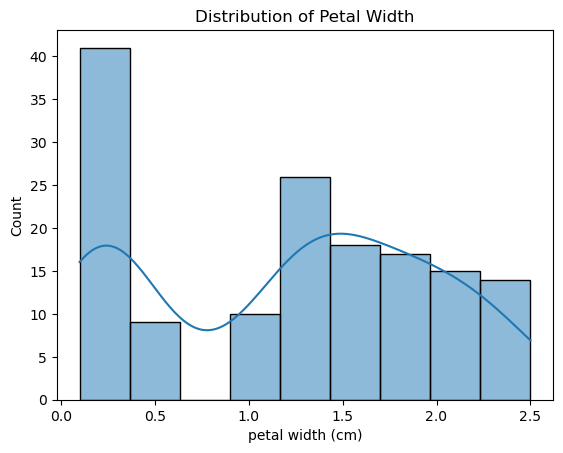

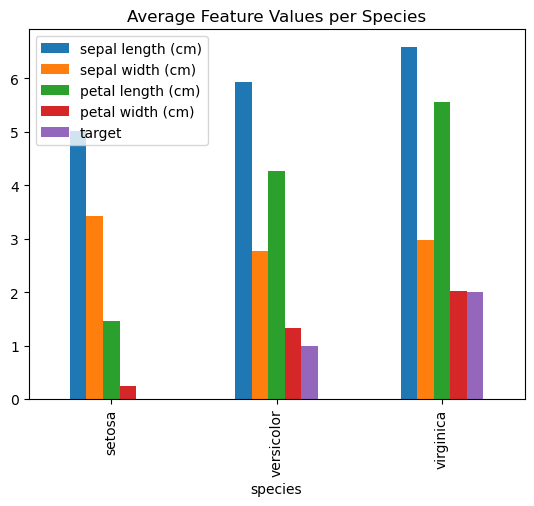

In [16]:
# 1. Pairplot
sns.pairplot(data1, hue='species')
plt.show()

# 2. Scatter Plot
plt.figure()
sns.scatterplot(
    x=data1['sepal length (cm)'],
    y=data1['sepal width (cm)'],
    hue=data1['species']
)
plt.title("Sepal Length vs Width")
plt.show()

# 3. Boxplot
plt.figure()
sns.boxplot(x='species', y='petal length (cm)', data=data1)
plt.title("Petal Length by Species")
plt.show()

# 4. Histogram
plt.figure()
sns.histplot(data1['petal width (cm)'], kde=True)
plt.title("Distribution of Petal Width")
plt.show()

# 5. Bar Chart 
mean_values = data1.groupby('species').mean(numeric_only=True)

mean_values.plot(kind='bar')
plt.title("Average Feature Values per Species")
plt.show()

## Preprocessing

In [17]:
X = data1.drop(['target', 'species'], axis=1)
y = data1['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Model

In [18]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

## Prediction

In [19]:
y_pred = model.predict(X_test)

## Evaluation

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



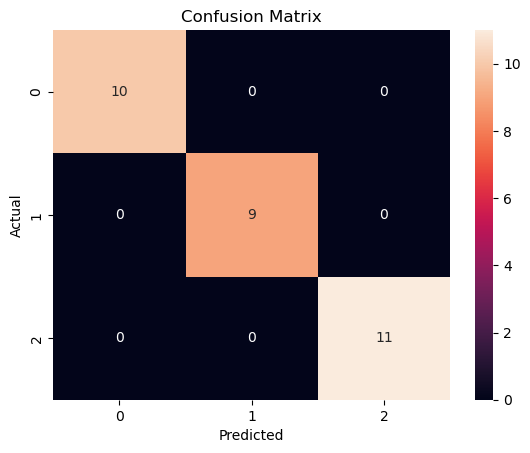

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

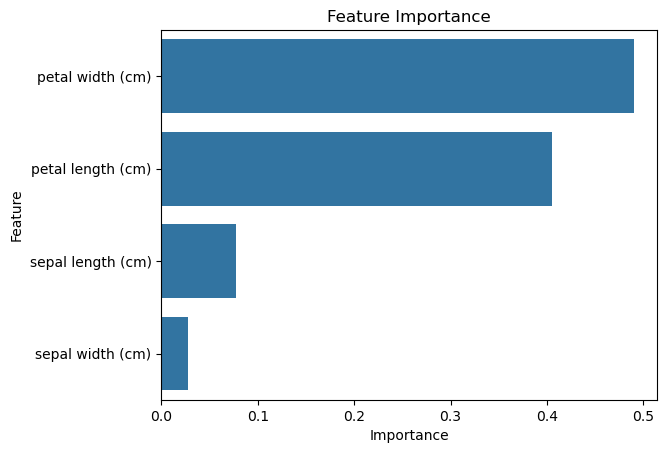

In [21]:
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance")
plt.show()

### Insights:

- Petal length and petal width are the most important features in classification.
- Setosa species is clearly separable from the other two classes.
- Versicolor and Virginica have some overlap but are still distinguishable.
- The model achieved high accuracy, indicating strong performance.
- No data leakage occurred as scaling was applied after train-test split.